- we have two types of scaling
    - z score(standardization)
    - min max scalar(normalization)
  

**z score**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file=r"C:\Users\Rao\Documents\Naresh IT\DATA FILES\Visadataset.csv"
visa_df=pd.read_csv(file)

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [7]:
#step1: take the prevailing wage data
#step2: calculate mean of the data
#step3: calculate std of the data
#step4: Numerator= data-mean   step1-step2
#step5: z_wage=numerator/std = step4/step3
#step6: create a new column visa_df['z_wage']=z_wage

In [17]:
wage_data=visa_df['prevailing_wage']
Mean=wage_data.mean()
std= wage_data.std()
Nr = wage_data-Mean
z_wage = Nr/std
visa_df['z_wage']=z_wage
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,z_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,-1.398510
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.169832
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.919060
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.169991
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,1.428576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.049923
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,3.876083
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,1.360253
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.221504


(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
        1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
        2.55368643e+05, 2.87289457e+05, 3.19210270e+05]),
 <BarContainer object of 10 artists>)

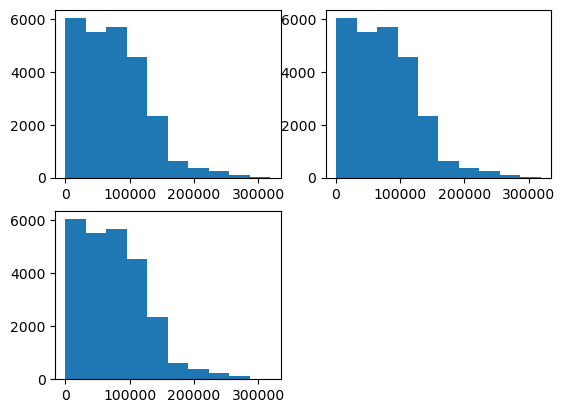

In [33]:
visa_df[['prevailing_wage','z_wage']]
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_data)
plt.subplot(2,2,3).hist(wage_data)



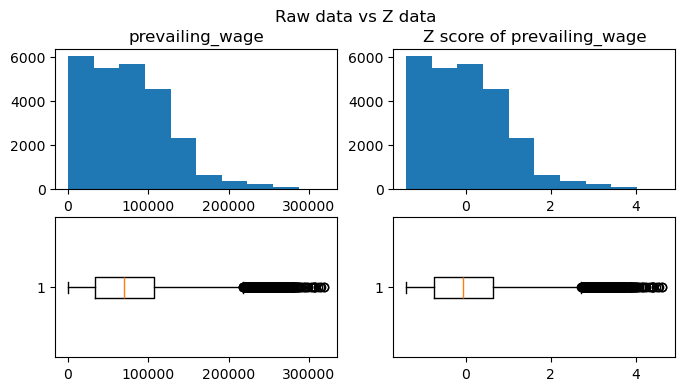

In [41]:
plt.figure(figsize=(8,4))
plt.suptitle('Raw data vs Z data')
plt.subplot(2,2,1).hist(wage_data)
plt.title('prevailing_wage')
plt.subplot(2,2,2).hist(z_wage)
plt.title('Z score of prevailing_wage')
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(z_wage,vert=False)
plt.show()

**STANDARD SCALAR**

- skleran

    - preprocessing
        - standardScalar


In [45]:
#step1: import method
#step2: save the method
#step3: apply fit transform

In [71]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
wage_ss=ss.fit_transform(visa_df[['prevailing_wage']]).values.reshape()
wage_ss

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [59]:
visa_df
visa_df['prevailing_wage']
visa_df['prevailing_wage'].values
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

**MINMAXSCALAR**

In [69]:
#step1L: read the data
#step2: calculate min
#step3: calculate max
#step4: step1-step2
#step5: Dr=Step3-step2
#step6: Nr/Dr
#step7: visa_df['wage_min_mac']=nr/Dr

In [73]:
wage_data=visa_df['prevailing_wage']
wage_data_min=wage_data.min()
wage_data_max=wage_data.max()
nr=wage_data-wage_data_min
dr=wage_data_max-wage_data_min
max(nr/dr),min(nr/dr)


(1.0, 0.0)

In [77]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
mms.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])